In [1]:
import pandas as pd
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import bte

In [2]:
tree = bte.MATree(pb_file = "/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 161.1474 seconds


In [19]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],['G15910T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],['G4162T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,['T13090C'],1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"['C1191T', 'C11674T']",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],['T15821C'],1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [ ]:
cols = ['G>A_llr','A>G_llr','C>T_llr','T>C_llr',]
df["sum_contexts"] = df[cols].fillna(0).sum(axis=1)
df["sum_contexts"]

0          0.000000
1          0.000000
2         -0.310864
3         -0.267798
4         -0.310864
             ...   
8906965   -1.370392
8906966   -1.036078
8906967    0.138013
8906968    0.766682
8906969   -0.368958
Name: sum_contexts, Length: 8906970, dtype: float64

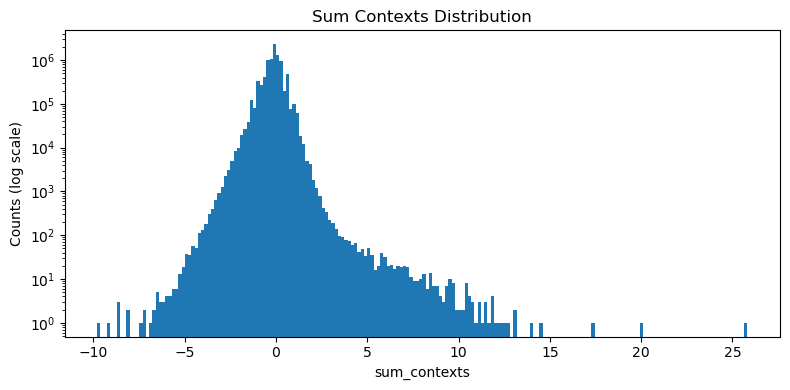

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["sum_contexts"], bins=200)
plt.yscale("log")
plt.xlabel("sum_contexts")
plt.ylabel("Counts (log scale)")
plt.title("Sum Contexts Distribution")
plt.tight_layout()
plt.show()



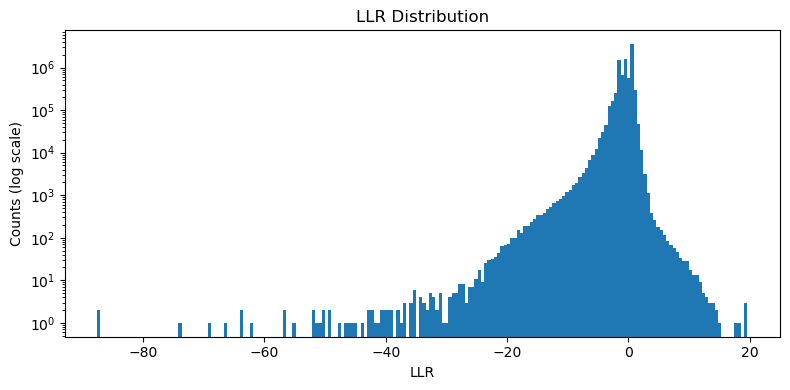

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["LLR"], bins=200)
plt.yscale("log")
plt.xlabel("LLR")
plt.ylabel("Counts (log scale)")
plt.title("LLR Distribution")
plt.tight_layout()
plt.show()



In [20]:
aus_fra = df[df["country"].isin(["Australia", "France"])].copy()


In [22]:
aus_fra["country"].value_counts()


country
France       326261
Australia    124093
Name: count, dtype: int64

In [27]:
aus_fra.drop(aus_fra[aus_fra["date"] == 2026].index, inplace=True)
aus_fra.drop(aus_fra[aus_fra["date"] == 0].index, inplace=True)

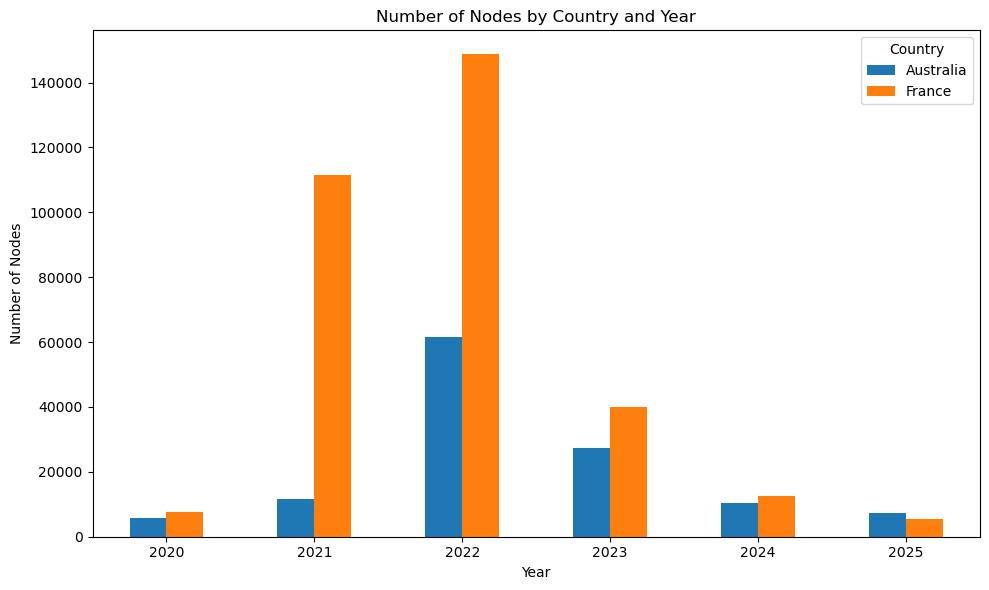

In [28]:
# Number of sequenced genomes in Australia and France over the years
aus_fra.groupby("country")["date"].value_counts().unstack().T.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Year")
plt.ylabel("Number of Nodes")
plt.title("Number of Nodes by Country and Year")
plt.legend(title="Country")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/reem/new_figs/Aus_vs_France_total_seqs_per_year.svg", format = "svg", bbox_inches="tight")
plt.show()


In [ ]:
aus_fra_2022 = aus_fra[(aus_fra["date"] == 2022)].copy()
aus_fra_2022.head()


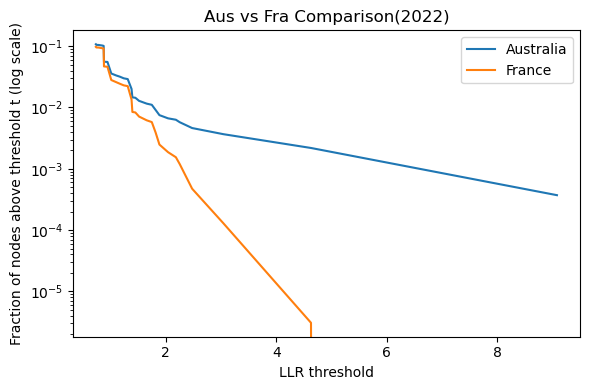

In [ ]:
# Tail LLR comparison: Australia vs France (2022)
import numpy as np
import matplotlib.pyplot as plt

au = aus_fra.loc[aus_fra.country=="Australia", "LLR"].to_numpy()
fr = aus_fra.loc[aus_fra.country=="France", "LLR"].to_numpy()

thresholds = np.quantile(np.concatenate([au, fr]), np.linspace(0.9, 0.9999, 200))  # Gets the 90th to 99th percentiles of LLR for both AU and FR and quantifies 200 thresholds within this range

au_surv = [(au >= t).mean() for t in thresholds]
fr_surv = [(fr >= t).mean() for t in thresholds]

plt.figure(figsize=(6,4))
plt.plot(thresholds, au_surv, label="Australia")
plt.plot(thresholds, fr_surv, label="France")
plt.yscale("log")
plt.xlabel("LLR threshold")
plt.ylabel("Fraction of nodes above threshold t (log scale)")
plt.title("Aus vs Fra Comparison(2022)")
plt.legend()
plt.tight_layout()
plt.show()


# Extreme mutation-pattern enrichment is more common in Australia in 2022
# LLRs only enriched in Australia at extreme thresholds
# Now check contexts as well


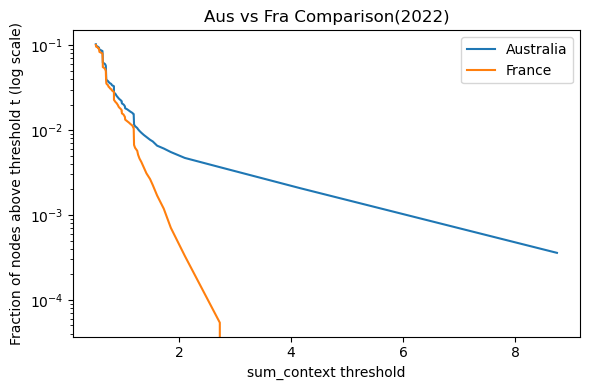

In [32]:
# Tail sum_contexts survival comparison: Australia vs France (2022)
import numpy as np
import matplotlib.pyplot as plt

au = aus_fra_2022.loc[aus_fra_2022.country=="Australia", "sum_contexts"].to_numpy()
fr = aus_fra_2022.loc[aus_fra_2022.country=="France", "sum_contexts"].to_numpy()

thresholds = np.quantile(np.concatenate([au, fr]), np.linspace(0.9, 0.9999, 200))  # Gets the 90th to 99th percentiles of sum_llrs for both AU and FR and quantifies 200 thresholds within this range

au_surv = [(au >= t).mean() for t in thresholds]
fr_surv = [(fr >= t).mean() for t in thresholds]

plt.figure(figsize=(6,4))
plt.plot(thresholds, au_surv, label="Australia")
plt.plot(thresholds, fr_surv, label="France")
plt.yscale("log")
plt.xlabel("sum_context threshold")
plt.ylabel("Fraction of nodes above threshold t (log scale)")
plt.title("Aus vs Fra Comparison(2022)")
plt.legend()
plt.tight_layout()
plt.show()

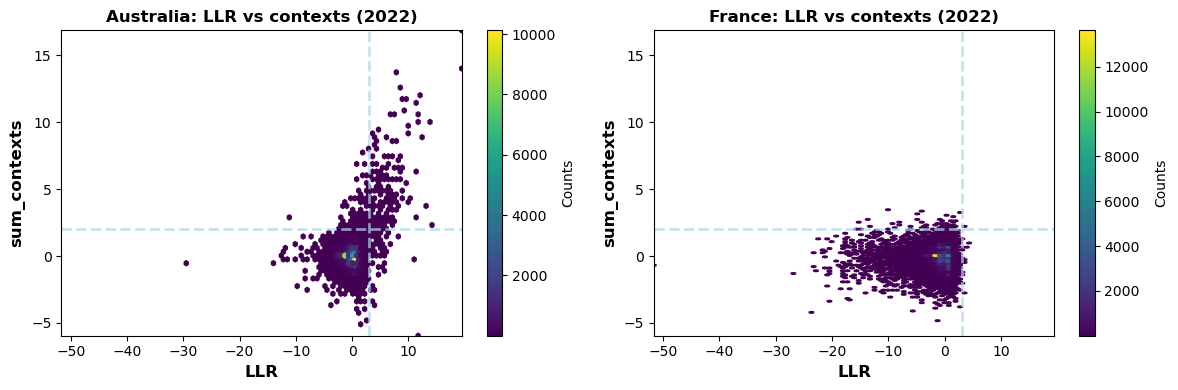

In [41]:
all_llr = aus_fra_2022["LLR"]
all_contexts = aus_fra_2022["sum_contexts"]

llr_min, llr_max = all_llr.min(), all_llr.max()
ctx_min, ctx_max = all_contexts.min(), all_contexts.max()

fig, axes = plt.subplots(1,2, figsize=(12,4))

ax = axes[0]
h1 = ax.hexbin(aus_fra_2022.loc[aus_fra_2022.country=="Australia","LLR"],
                aus_fra_2022.loc[aus_fra_2022.country=="Australia","sum_contexts"],
                gridsize=70, mincnt=1, cmap='viridis', xscale='linear', yscale='linear')
ax.set_xlim(llr_min, llr_max)
ax.set_ylim(ctx_min, ctx_max)
ax.axvline(x=3, color='lightblue', linestyle='--', linewidth=2, alpha=0.7, label='LLR > 3') 
ax.axhline(y=2, color='lightblue', linestyle='--', linewidth=2, alpha=0.7, label='sum_contexts > 2')
ax.set_xlabel("LLR", fontsize=12, fontweight = 'bold'); ax.set_ylabel("sum_contexts", fontsize=12, fontweight = 'bold')
ax.set_title("Australia: LLR vs contexts (2022)", fontsize=12, fontweight = 'bold')
plt.colorbar(h1, ax=ax, label='Counts')

ax = axes[1]
h2 = ax.hexbin(aus_fra_2022.loc[aus_fra_2022.country=="France","LLR"],
                aus_fra_2022.loc[aus_fra_2022.country=="France","sum_contexts"],
                gridsize=70, mincnt=1, cmap='viridis', xscale='linear', yscale='linear')
ax.set_xlim(llr_min, llr_max)
ax.set_ylim(ctx_min, ctx_max)
ax.axvline(x=3, color='lightblue', linestyle='--', linewidth=2, alpha=0.7, label='LLR > 3')
ax.axhline(y=2, color='lightblue', linestyle='--', linewidth=2, alpha=0.7, label='sum_contexts > 2')
ax.set_xlabel("LLR", fontsize=12, fontweight = 'bold'); ax.set_ylabel("sum_contexts", fontsize=12, fontweight = 'bold')
ax.set_title("France: LLR vs contexts (2022)", fontsize=12, fontweight = 'bold') 
plt.colorbar(h2, ax=ax, label='Counts')

plt.tight_layout()
plt.show()

# Australian nodes with strong MOV-like mutation patterns also accumulate context evidence. Also, Australia has many more nodes with extreme LLRs. High LLRs and high context co-occur.
# Extreme LLRs in France are rarer, and less consistently supported by context.


In [42]:
import plotly.figure_factory as ff
import plotly.express as px
import numpy as np

# Threshold sweep heatmap
LLR_thresh = [1,2,3,4,5,6,7,10,12]
sum_context_thresh = [1,2,3,4,5,6,7,10,12] 

# Create a grid to hold results
rows = []
for llr_t in LLR_thresh:
    for ctx_t in sum_context_thresh:
        Mov_pred = (aus_fra_2022["LLR"] > llr_t) & (aus_fra_2022["sum_contexts"] > ctx_t)
        rows.append({
            "LLR_thresh": llr_t,
            "sum_context_thresh": ctx_t,
            "Australia_counts": Mov_pred[aus_fra_2022["country"]=="Australia"].sum(),
            "France_counts": Mov_pred[aus_fra_2022["country"]=="France"].sum(),
            "contrast": Mov_pred[aus_fra_2022["country"]=="Australia"].sum() - Mov_pred[aus_fra_2022["country"]=="France"].sum()
        })
heatmap_df = pd.DataFrame(rows)
heatmap_pivot = heatmap_df.pivot(index="sum_context_thresh", columns="LLR_thresh", values="contrast")

# Plot heatmap
fig = px.imshow(heatmap_pivot,
                labels=dict(x="LLR_thresh", y="sum_context_thresh", color="contrast"),
                x=LLR_thresh,
                y=sum_context_thresh,
                text_auto="auto",
                aspect = "equal",
                title="Difference in MOV-like counts (Australia - France) in 2022")
fig.update_xaxes(constrain="domain")
fig.update_yaxes(autorange=True)
fig.update_layout(width=800, height=800)
fig.show()  
      


In [ ]:
# Plot grouped barplot with thresholds LLR>2 and sum_contexts>2
rows = []
Years = [2020, 2021, 2022, 2023, 2024, 2025]

for year in Years:
    aus_fra_yr = aus_fra[aus_fra["date"]==year]
    Mov_pred = (aus_fra_yr["LLR"] > 3) & (aus_fra_yr["sum_contexts"] > 2)
    rows.append({
        "Australia_counts": Mov_pred[aus_fra_yr["country"]=="Australia"].sum(),
        "France_counts": Mov_pred[aus_fra_yr["country"]=="France"].sum(),
        "year": year,
    })
plotly_df = pd.DataFrame(rows)  

fig = px.bar(plotly_df, x="year", y=["Australia_counts", "France_counts"],
             barmode = 'group')
fig.show()                                        

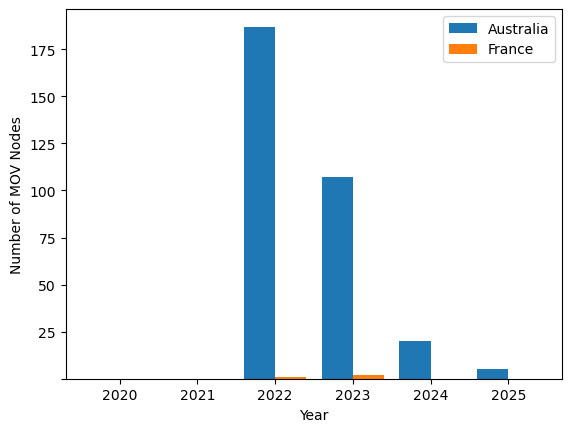

In [ ]:
# Same fig with matplotlib instead of plotly
plt.bar(plotly_df["year"]-0.2, plotly_df["Australia_counts"], width=0.4, label="Australia")
plt.bar(plotly_df["year"]+0.2, plotly_df["France_counts"], width=0.4, label="France")
plt.xlabel("Year")
plt.ylabel("Number of MOV Nodes")
plt.legend()
plt.rcParams['font.size'] = 10
ax = plt.gca()
ax.yaxis.get_major_ticks()[0].label1.set_visible(False)
plt.savefig("/Users/reem/new_figs/Aus_vs_Fra_mov.svg", format="svg", bbox_inches = 'tight')
plt.show()

In [49]:
countries = ['Australia','France']
thresholds = [1, 2, 3, 4, 5, 6, 7, 10, 12]
for t in thresholds:
    for country in countries:
        count = len(aus_fra_2022[(aus_fra_2022['sum_contexts'] > t) & (aus_fra_2022['node_id'].str.contains(f"/{country}/"))])
        print(f"Number of sequences from {country} with sum_contexts > {t}: {count}")

Number of sequences from Australia with sum_contexts > 1: 84
Number of sequences from France with sum_contexts > 1: 1
Number of sequences from Australia with sum_contexts > 2: 79
Number of sequences from France with sum_contexts > 2: 0
Number of sequences from Australia with sum_contexts > 3: 73
Number of sequences from France with sum_contexts > 3: 0
Number of sequences from Australia with sum_contexts > 4: 62
Number of sequences from France with sum_contexts > 4: 0
Number of sequences from Australia with sum_contexts > 5: 43
Number of sequences from France with sum_contexts > 5: 0
Number of sequences from Australia with sum_contexts > 6: 34
Number of sequences from France with sum_contexts > 6: 0
Number of sequences from Australia with sum_contexts > 7: 25
Number of sequences from France with sum_contexts > 7: 0
Number of sequences from Australia with sum_contexts > 10: 10
Number of sequences from France with sum_contexts > 10: 0
Number of sequences from Australia with sum_contexts >

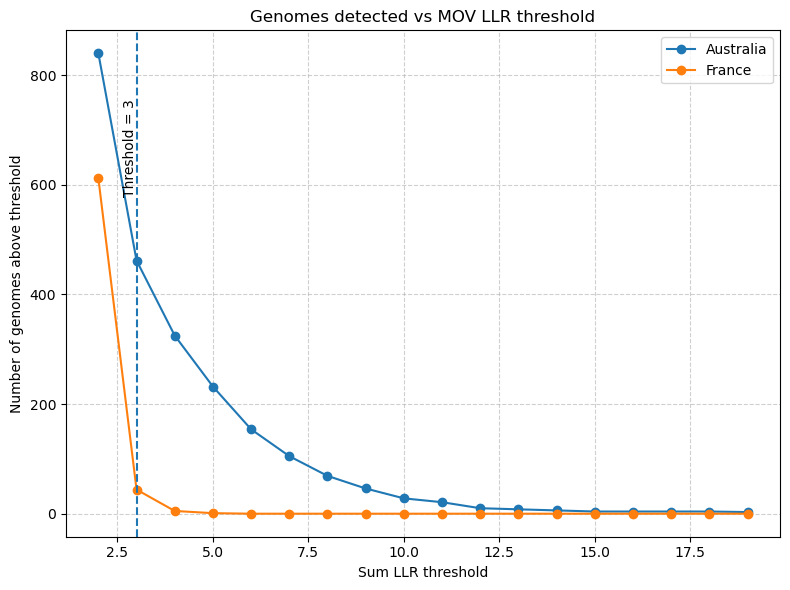

In [53]:

plt.figure(figsize=(8, 6))
thresholds = range(2, 20, 1)
australia_counts = [(df[df['country']=='Australia']['LLR'] > t).sum() for t in thresholds]
france_counts = [(df[df['country']=='France']['LLR'] > t).sum() for t in thresholds]

plt.plot(thresholds, australia_counts, marker="o", label="Australia")
plt.plot(thresholds, france_counts, marker="o", label="France")

# Highlight threshold = 3
plt.axvline(3, linestyle="--")
plt.text(3, max(max(australia_counts), max(france_counts))*0.9, "Threshold = 3", rotation=90, va="top", ha="right")

plt.xlabel("Sum LLR threshold")
plt.ylabel("Number of genomes above threshold")
plt.title("Genomes detected vs MOV LLR threshold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


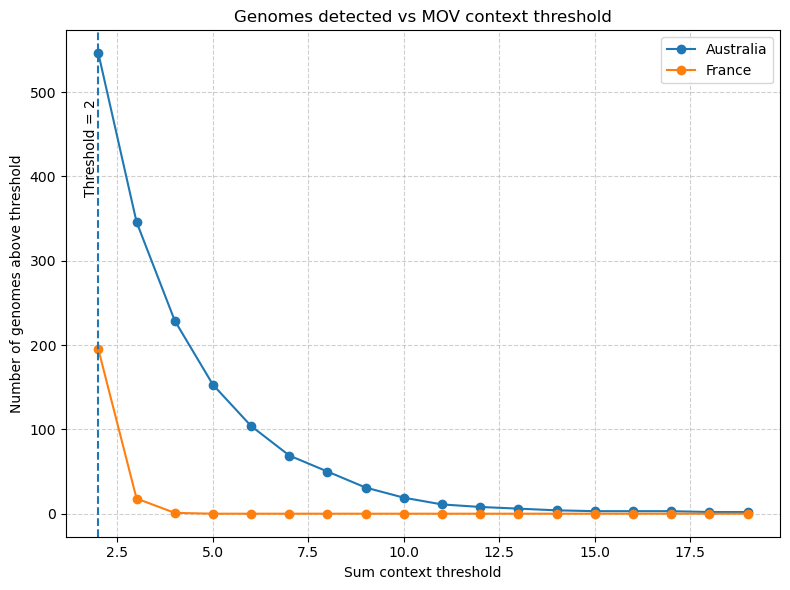

In [56]:

plt.figure(figsize=(8, 6))
thresholds = range(2, 20, 1)
australia_counts = [(df[df['country']=='Australia']['sum_contexts'] > t).sum() for t in thresholds]
france_counts = [(df[df['country']=='France']['sum_contexts'] > t).sum() for t in thresholds]

plt.plot(thresholds, australia_counts, marker="o", label="Australia")
plt.plot(thresholds, france_counts, marker="o", label="France")

# Highlight threshold = 6
plt.axvline(2, linestyle="--")
plt.text(2, max(max(australia_counts), max(france_counts))*0.9, "Threshold = 2", rotation=90, va="top", ha="right")

plt.xlabel("Sum context threshold")
plt.ylabel("Number of genomes above threshold")
plt.title("Genomes detected vs MOV context threshold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

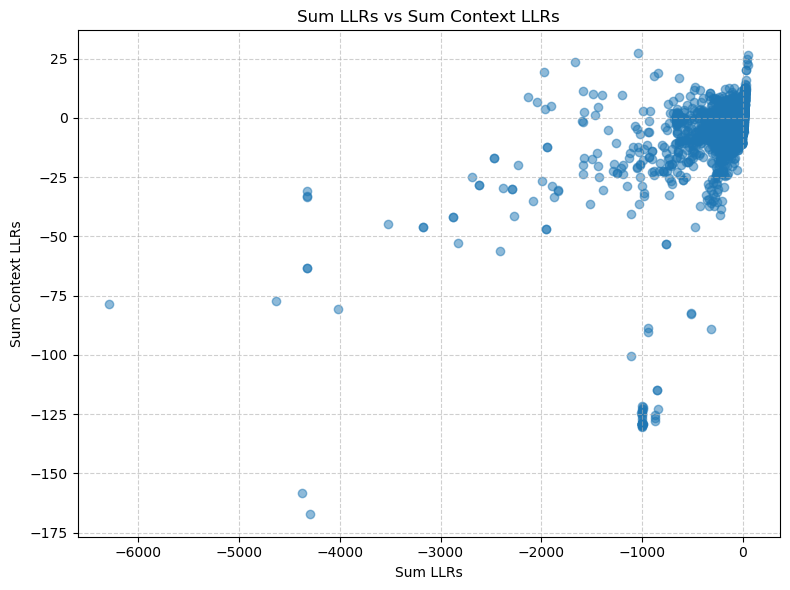

In [55]:
# Sum_llrs vs Sum_context plot
plt.figure(figsize=(8, 6))
plt.scatter(df['sum_llrs'], df['sum_context'], alpha=0.5)
plt.xlabel('Sum LLRs')
plt.ylabel('Sum Context LLRs')
plt.title('Sum LLRs vs Sum Context LLRs')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
mov_df = df[(df['LLR'] > 3) & (df['sum_contexts'] > 2)]   

mov_df.head()

In [32]:
mov_df.to_csv("/Users/reem/mov_llr_context_3_2.tsv", sep="\t", index=False)

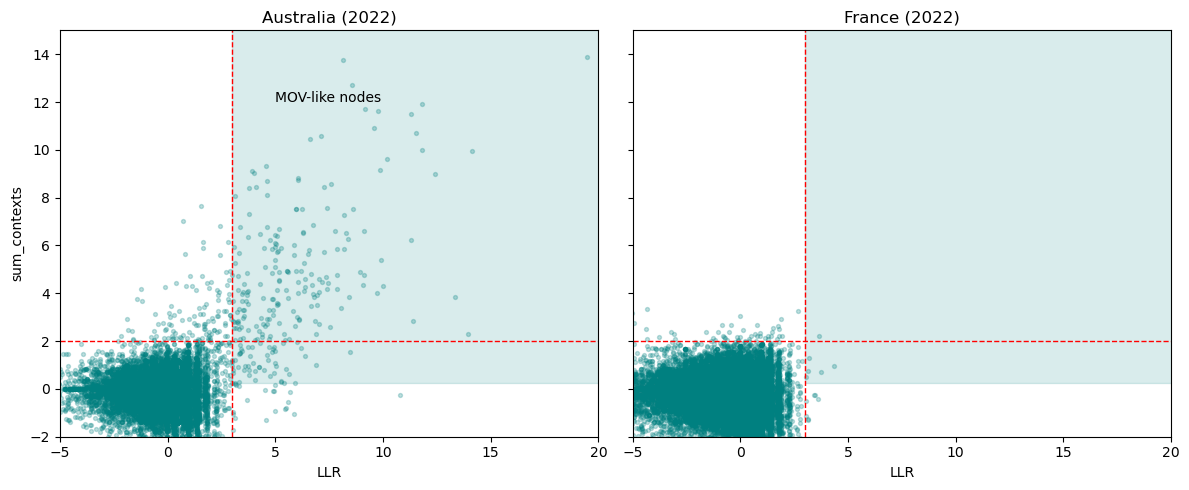

In [55]:
# Scatter plots for Australia and France (2022)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, country in zip(axes, ["Australia", "France"]):
    d = aus_fra_2022[aus_fra_2022.country == country]

    # Scatter with transparency
    ax.scatter(
        d["LLR"],
        d["sum_contexts"],
        s=8,
        alpha=0.25,
        color="teal"
    )

    # Shade MOV region
    ax.axvspan(3, 25, ymin=(2 - 0)/(15 - 0), ymax=1,
               color="teal", alpha=0.15, label="MOV region")

    ax.axvline(3, color="red", linestyle="--", linewidth=1)
    ax.axhline(2, color="red", linestyle="--", linewidth=1)

    ax.set_title(f"{country} (2022)")
    ax.set_xlabel("LLR")

axes[0].set_ylabel("sum_contexts")


axes[0].set_xlim(-5, 20)
axes[0].set_ylim(-2, 15)
axes[0].text(5, 12, "MOV-like nodes", color="black", fontsize=10)

plt.tight_layout()
plt.show()



In [ ]:
# Compare MOV detection methods: Sanderson et al. (2023), Focosi et al. (2023), and LLR-context method

import ast
import numpy as np

df["Counts_parsed"] = df["Counts"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df["GtoA_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("G>A", 0) if isinstance(x, dict) else 0)
df["AtoG_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("A>G", 0) if isinstance(x, dict) else 0)
df["CtoT_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("C>T", 0) if isinstance(x, dict) else 0)
df["TtoC_counts_int"] = df["Counts_parsed"].apply(lambda x: x.get("T>C", 0) if isinstance(x, dict) else 0)

# Total transition counts
df["transition_counts"] = (df["GtoA_counts_int"] + df["AtoG_counts_int"] + 
                           df["CtoT_counts_int"] + df["TtoC_counts_int"])

# Proportions
df["GtoA_prop"] = df["GtoA_counts_int"] / df["num_mutations"]
df["CtoT_prop"] = df["CtoT_counts_int"] / df["num_mutations"]
df["transition_prop"] = df["transition_counts"] / df["num_mutations"]

# ============================================================
# CALCULATE Ts/Tv RATIO FOR FOCOSI METHOD
# ============================================================

# Transversions = total mutations - transitions
df["transversions"] = df["num_mutations"] - df["transition_counts"]

# Ts/Tv ratio (handle division by zero)
df["ts_tv_ratio"] = df["transition_counts"] / df["transversions"].replace(0, np.inf)

# ============================================================
# DEFINE ALL THREE DETECTION METHODS
# ============================================================

# Sanderson et al. (2023)
sanderson_mov = (
    (df["GtoA_prop"] > 0.25) &
    (df["CtoT_prop"] > 0.20) &
    (df["transition_prop"] > 0.90) &
    (df["num_mutations"] >= 10)
)

# Focosi et al. (threshold-based with Ts/Tv)
focosi_mov = (
    (df["transition_counts"] >= 13) &           # Ts >= 13
    (df["GtoA_prop"] >= 0.20) &                 # G->A >= 20%
    (df["ts_tv_ratio"] > 3)                     # Ts/Tv > 3
)

# Your model's LLR method
llr_mov = (df["LLR"] > 3) & (df["sum_contexts"] > 2)

# ============================================================
# PRE-2021 FALSE POSITIVE ANALYSIS
# ============================================================

df["date"] = pd.to_numeric(df["date"], errors="coerce")
pre_2021 = df[df["date"] < 2021]

sanderson_fp = sanderson_mov & (df["date"] < 2021)
focosi_fp = focosi_mov & (df["date"] < 2021)
llr_fp = llr_mov & (df["date"] < 2021)

print("=== FALSE POSITIVE RATES (pre-2021) ===")
print(f"Total pre-2021 nodes: {len(pre_2021)}")
print(f"\nSanderson:")
print(f"  FP count: {sanderson_fp.sum()}")
print(f"  FP rate: {sanderson_fp.sum() / len(pre_2021) * 100:.4f}%")
print(f"\nFocosi:")
print(f"  FP count: {focosi_fp.sum()}")
print(f"  FP rate: {focosi_fp.sum() / len(pre_2021) * 100:.4f}%")
print(f"\nLLR:")
print(f"  FP count: {llr_fp.sum()}")
print(f"  FP rate: {llr_fp.sum() / len(pre_2021) * 100:.4f}%")

print(f"\n=== SANDERSON FALSE POSITIVES (pre-2021) ===")
sanderson_fps_df = df[sanderson_fp][["node_id", "date", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(sanderson_fps_df)}")
if len(sanderson_fps_df) > 0:
    print(sanderson_fps_df.head(10))

print(f"\n=== FOCOSI FALSE POSITIVES (pre-2021) ===")
focosi_fps_df = df[focosi_fp][["node_id", "date", "num_mutations", "GtoA_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(focosi_fps_df)}")
if len(focosi_fps_df) > 0:
    print(focosi_fps_df.head(10))

print(f"\n=== LLR FALSE POSITIVES (pre-2021) ===")
llr_fps_df = df[llr_fp][["node_id", "date", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop", "transition_counts", "ts_tv_ratio", "LLR", "sum_contexts"]]
print(f"Count: {len(llr_fps_df)}")
if len(llr_fps_df) > 0:
    print(llr_fps_df.head(10))



=== FALSE POSITIVE RATES (pre-2021) ===
Total pre-2021 nodes: 399352

Sanderson:
  FP count: 12
  FP rate: 0.0030%

Focosi:
  FP count: 6
  FP rate: 0.0015%

LLR:
  FP count: 2
  FP rate: 0.0005%

=== SANDERSON FALSE POSITIVES (pre-2021) ===
Count: 12
                                                   node_id  date  \
12724    India/HR-NCDC-909300/2020|EPI_ISL_2459299|2020...  2020   
211220   India/CH-ICMR-MCL_4036_5642/2020|EPI_ISL_34736...  2020   
417522   Denmark/DCGC-21722/2020|EPI_ISL_758327|2020-12-21  2020   
442839                                         node_207183  2020   
484508   hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022...  2020   
516097                                         node_240680  2020   
516887   Philippines/PH-PGC-00060/2020|EPI_ISL_2154019|...  2020   
520176                                         node_242423  2020   
522384   Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...  2020   
8754928   Peru/LIM-INS-193/2020|EPI_ISL_1092344|2020-09-02  2020   


In [ ]:
# ============================================================
# APPLY ALL THREE METHODS TO AUS + FRANCE DATA
# ============================================================

# Filter to Australia and France only
aus_france = df[df["country"].isin(["Australia", "France"])].copy()

# ============================================================
# DEFINE ALL THREE METHODS
# ============================================================

# Sanderson et al.
sanderson = (
    (aus_france["GtoA_prop"] > 0.25) &
    (aus_france["CtoT_prop"] > 0.20) &
    (aus_france["transition_prop"] > 0.90) &
    (aus_france["num_mutations"] >= 10)
)

# Focosi et al.
focosi = (
    (aus_france["transition_counts"] >= 13) &
    (aus_france["GtoA_prop"] >= 0.20) &
    (aus_france["ts_tv_ratio"] > 3)
)

# LLR 
llr = (aus_france["LLR"] > 3) & (aus_france["sum_contexts"] > 2)

# ============================================================
# SENSITIVITY & SPECIFICITY ANALYSIS
# ============================================================

aus_mask = aus_france["country"] == "Australia"
fra_mask = aus_france["country"] == "France"

total_aus = aus_mask.sum()
total_fra = fra_mask.sum()

print("SENSITIVITY & SPECIFICITY COMPARISON (Australia vs France)")


print(f"\nTotal Australia nodes: {total_aus}")
print(f"Total France nodes: {total_fra}\n")

# Calculate for each method
methods_data = {
    "Sanderson": sanderson,
    "Focosi": focosi,
    "LLR": llr
}

results = []

for method_name, method_calls in methods_data.items():
    # Detections in Australia (sensitivity - higher is better)
    aus_detected = (method_calls & aus_mask).sum()
    sensitivity = 100 * aus_detected / total_aus
    
    # Detections in France (false positives - lower is better)
    fra_detected = (method_calls & fra_mask).sum()
    specificity = 100 * (1 - fra_detected / total_fra)  # 1 - FPR
    
    results.append({
        "Method": method_name,
        "Aus detected": aus_detected,
        "Aus %": sensitivity,
        "Fra detected": fra_detected,
        "Fra %": 100 * fra_detected / total_fra,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })
    
    print(f"{method_name}:")
    print(f"  Australia: {aus_detected}/{total_aus} ({sensitivity:.2f}%)")
    print(f"  France: {fra_detected}/{total_fra} ({100*fra_detected/total_fra:.2f}%)")
    print(f"  Sensitivity: {sensitivity:.2f}%")
    print(f"  Specificity: {specificity:.2f}%")
    print()

# Create comparison table
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df.to_string(index=False))

# ============================================================
# IDENTIFY WHICH METHOD IS BEST
# ============================================================

print("\nSensitivity (Australia detection)")
for i, row in results_df.sort_values("Sensitivity", ascending=False).iterrows():
    print(f"  {i+1}. {row['Method']}: {row['Sensitivity']:.2f}%")

print("\nSpecificity (France rejection)")
for i, row in results_df.sort_values("Specificity", ascending=False).iterrows():
    print(f"  {i+1}. {row['Method']}: {row['Specificity']:.2f}%")

# Combined score (you could use different weighting)
results_df["Score"] = results_df["Sensitivity"] + results_df["Specificity"]
print("\nCombined Score (Sens + Spec)")
for i, row in results_df.sort_values("Score", ascending=False).iterrows():
    print(f"  {i+1}. {row['Method']}: {row['Score']:.2f}")

# ============================================================
# DETAILED BREAKDOWN
# ============================================================

print("\n" + "=" * 80)
print("DETAILED BREAKDOWN")
print("=" * 80)

print("\nSanderson detections in Australia:")
san_aus = aus_france[sanderson & aus_mask][["node_id", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop"]]
print(f"Count: {len(san_aus)}")
if len(san_aus) > 0:
    print(san_aus.head())

print("\n\nFocosi detections in Australia:")
foc_aus = aus_france[focosi & aus_mask][["node_id", "num_mutations", "GtoA_prop", "transition_counts", "ts_tv_ratio"]]
print(f"Count: {len(foc_aus)}")
if len(foc_aus) > 0:
    print(foc_aus.head())

print("\n\nLLR detections in Australia:")
llr_aus = aus_france[llr & aus_mask][["node_id", "num_mutations", "GtoA_prop", "LLR", "sum_contexts"]]
print(f"Count: {len(llr_aus)}")
if len(llr_aus) > 0:
    print(llr_aus.head())

print("\n\nSanderson detections in France (FALSE POSITIVES):")
san_fra = aus_france[sanderson & fra_mask][["node_id", "num_mutations", "GtoA_prop", "CtoT_prop", "transition_prop"]]
print(f"Count: {len(san_fra)}")
if len(san_fra) > 0:
    print(san_fra.head())

print("\n\nFocosi detections in France (FALSE POSITIVES):")
foc_fra = aus_france[focosi & fra_mask][["node_id", "num_mutations", "GtoA_prop", "transition_counts", "ts_tv_ratio"]]
print(f"Count: {len(foc_fra)}")
if len(foc_fra) > 0:
    print(foc_fra.head())

print("\n\nLLR detections in France (FALSE POSITIVES):")
llr_fra = aus_france[llr & fra_mask][["node_id", "num_mutations", "GtoA_prop", "LLR", "sum_contexts"]]
print(f"Count: {len(llr_fra)}")
if len(llr_fra) > 0:
    print(llr_fra.head())



SENSITIVITY & SPECIFICITY COMPARISON (Australia vs France)

Total Australia nodes: 124093
Total France nodes: 326261

Sanderson:
  Australia: 420/124093 (0.34%)
  France: 10/326261 (0.00%)
  Sensitivity: 0.34%
  Specificity: 100.00%

Focosi:
  Australia: 155/124093 (0.12%)
  France: 7/326261 (0.00%)
  Sensitivity: 0.12%
  Specificity: 100.00%

LLR:
  Australia: 319/124093 (0.26%)
  France: 3/326261 (0.00%)
  Sensitivity: 0.26%
  Specificity: 100.00%


SUMMARY TABLE
   Method  Aus detected    Aus %  Fra detected    Fra %  Sensitivity  Specificity
Sanderson           420 0.338456            10 0.003065     0.338456    99.996935
   Focosi           155 0.124906             7 0.002146     0.124906    99.997854
      LLR           319 0.257065             3 0.000920     0.257065    99.999080

Sensitivity (Australia detection)
  1. Sanderson: 0.34%
  3. LLR: 0.26%
  2. Focosi: 0.12%

Specificity (France rejection)
  3. LLR: 100.00%
  2. Focosi: 100.00%
  1. Sanderson: 100.00%

Combined Score

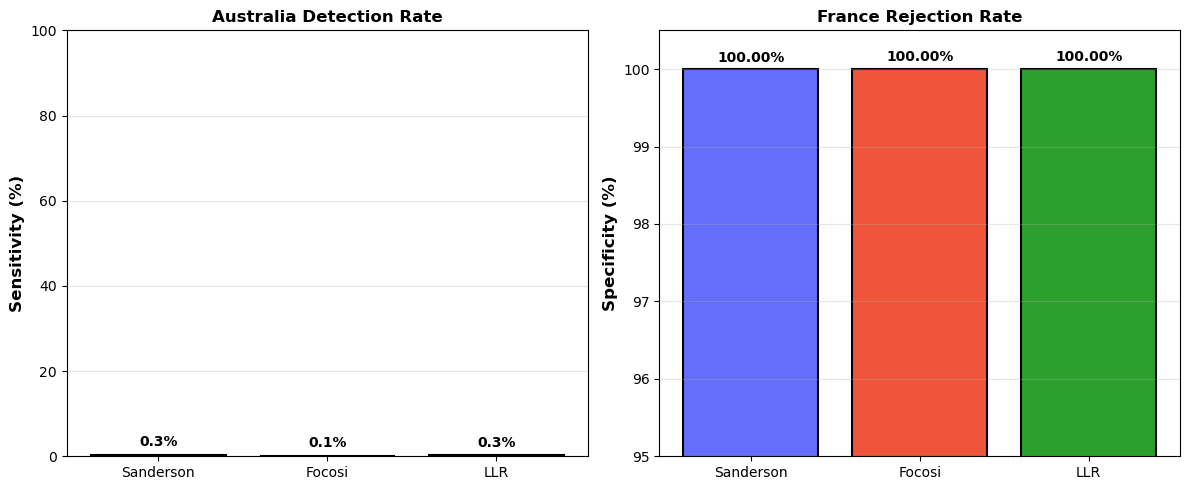

In [ ]:
# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Sensitivity comparison
ax = axes[0]
methods = results_df["Method"].values
sens = results_df["Sensitivity"].values
colors = ["#636EFA", "#EF553B", "#2ca02c"]
ax.bar(methods, sens, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Sensitivity (%)", fontsize=12, fontweight='bold')
ax.set_title("Australia Detection Rate", fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])
for i, v in enumerate(sens):
    ax.text(i, v+2, f"{v:.1f}%", ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel B: Specificity comparison
ax = axes[1]
spec = results_df["Specificity"].values
ax.bar(methods, spec, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Specificity (%)", fontsize=12, fontweight='bold')
ax.set_title("France Rejection Rate", fontsize=12, fontweight='bold')
ax.set_ylim([95, 100.5])
for i, v in enumerate(spec):
    ax.text(i, v+0.1, f"{v:.2f}%", ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig("/Users/reem/molnupiravir_paper/Figures/aus_fra_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()